# Analog experiment tutorial through example

This notebook demonstrates how to utilize our analog experiment infrastructure to simulate the Kibble-Zurek (KZ) mechanism on a quantum processor.

Unlike traditional digital quantum computing—where programs are built using discrete quantum gates—analog experiments follow a trajectory-based workflow:
- Define the Trajectory: Specify the time-dependent frequency paths for both qubits and couplers.
- Circuit Generation: Use our automated tools to translate these physical trajectories into the underlying control gates.
- Execution & Analysis: Run the experiment on the quantum engine and perform post-processing on the resulting measurement data.

In [ ]:
# @title install dependencies
!pip install --upgrade --quiet cirq==1.7.0.dev20251110175708 # Or future version

import collections
import itertools

import attrs
import cirq
import cirq_google
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import sympy
import tunits as tu

from cirq_google.engine.qcs_notebook import authenticate_user
from cirq_google.experimental import analog_experiments as aexp

ERROR: Could not find a version that satisfies the requirement cirq==1.7.0.dev20251110175708 (from versions: none)
ERROR: No matching distribution found for cirq==1.7.0.dev20251110175708


# Quantum Engine Sampler Setup

Please fill the following gcp_proj, device_name, config_name, and snapshot_id properly.

In [ ]:
gcp_proj = ""  # @param{type: "string", "placeholder": "Enter your own project"}
device_name = ""  # @param{type: "string"}
config_name = ""  # @param{type: "string"}
snapshot_id = ""  # @param{type: "string"}

authenticate_user()
engine = cirq_google.get_engine(gcp_proj)
remote_sampler = engine.get_sampler(
    device_name, snapshot_id=snapshot_id, device_config_name=config_name
)

This is an example colab to show how to use the cirq google feature to run the digital-analog experiment.

# Set up qubits and couplers

In [ ]:
# We use GridQubit to identify a qubit. cirq.q(5, 4) represents a qubit at
# xy-coordinate (5, 4). We also use string `q5_4` for short representation.
# When the distance between two qubits in a pair is 1, that also uniquely
# identifies a coupler, i.e. `(q5_4, q5_5)` corresponds to one coupler while
# `(q5_4, q6_5)` is just a pair of qubits with no associated coupler.
metadata = (
    engine.get_processor(device_name)
    .get_config_from_run(config_name=config_name)
    .effective_device.metadata
)
# Find all qubits and couplers on the device.
qubits = list(metadata.qubit_set)
couplers = [cirq_google.Coupler(*sorted(pair)) for pair in metadata.qubit_pairs]

# Check readout fidelity

Before running experiments, we should first verify the readout fidelity. It is best practice to confirm the processor is in a healthy state to ensure reliable results.

In [ ]:
RO_err = cirq.estimate_parallel_single_qubit_readout_errors(sampler=remote_sampler, qubits=qubits)
RO_fid = {q: 1 - RO_err.one_state_errors[q] - RO_err.zero_state_errors[q] for q in qubits}

(<Axes: title={'center': '$|0\\rangle$ errors'}, xlabel='column', ylabel='row'>,
 <Axes: title={'center': '$|1\\rangle$ errors'}, xlabel='column', ylabel='row'>)

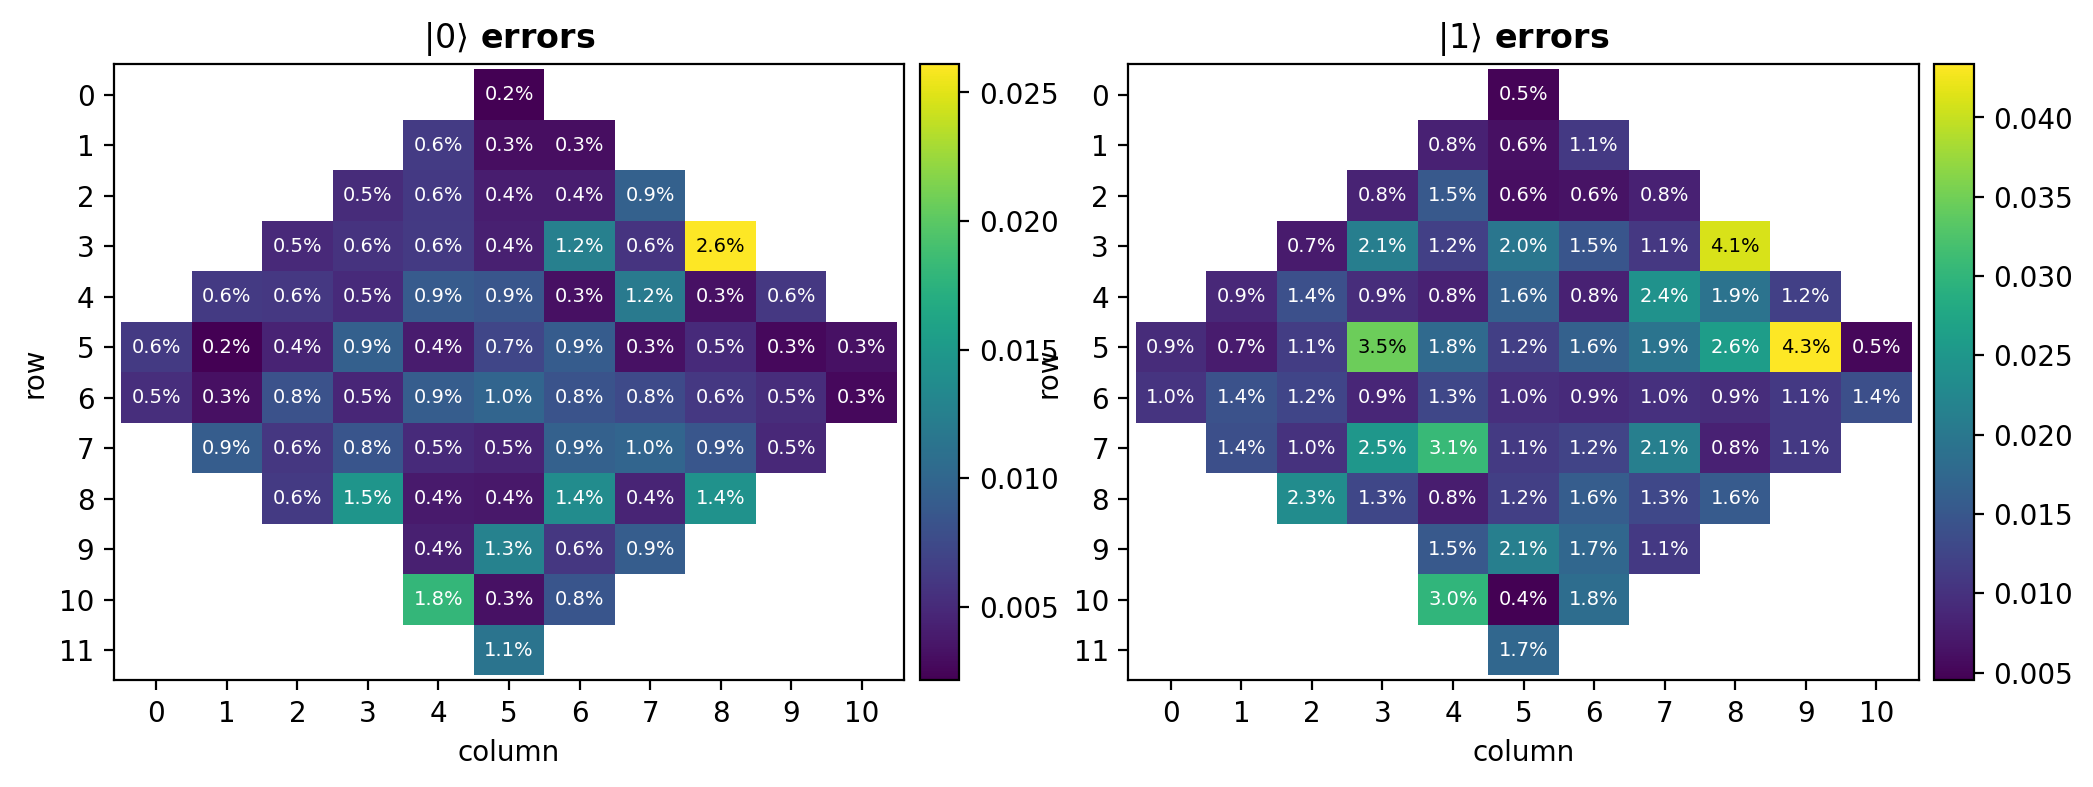

In [ ]:
RO_err.plot_heatmap(annotation_text_kwargs={"fontsize": 7})

# **Intro to classes for generating analog circuits**

## **AnalogTrajectory: designing the circuit**

To design an analog circuit, we use the AnalogTrajectory class. Specifically, the trajectories of the qubit frequencies and coupling strength are defined via the `aexp.AnalogTrajectory.from_sparse_trajectory(trajectory, ...)` classmethod, where the `trajectory` argument is a standard Python list of three-element tuples, corresponding to each change in the Hamiltonian with time. In each tuple, we specify the duration of the change, the qubit frequency at the end of that step, as well as the final coupling strength. For instance, the tuple (10*ns,{},{('q5_6','q6_6'):-5*MHz}) indicates that the coupling between qubits q5_6 and q6_6 should be ramped to -5 MHz over the course of 10 ns, while leaving all other parameters the same. Refer to the `make_trajectory` function below for a concrete implementation.

In [ ]:
#Let's make a simple analog circuit on two qubits:
qubits=['q5_5','q5_6']
couplers=[('q5_5','q5_6')]
trajectory=[(10*tu.ns,{q:0*tu.MHz for q in qubits},{}), #Ramp the qubits from idle to resonance over 10 ns
            (50*tu.ns, {},{('q5_5','q5_6'):-5*tu.MHz}), #Ramp up the coupling to -5 MHz over 20 ns
            (50*tu.ns,{'q5_5':10*tu.MHz},{('q5_5','q5_6'):-10*tu.MHz}), #Detune q5_5 by 10 MHz over 50 ns, while simultaneously raising the coupling to -10 MHz
            (100*tu.ns,{},{}), #Just wait for 100 ns
            (3*tu.ns,{q:None for q in qubits},{c:0*tu.MHz for c in couplers})] #Bring qubits back to idle (indicated by None) and coupling back to zero

#Define AnalogTrajectory instance:
analog_trajectory=aexp.AnalogTrajectory.from_sparse_trajectory(
        trajectory, qubits=qubits, couplers=couplers
    )

In [ ]:
# We next visualize the trajectory. Note that the idle qubit frequencies
# (seen at the beginning and end) are randomly generated to give a qualitatively
# correct picture
ax1, ax2 = analog_trajectory.plot()
ax1.legend().set_visible(False)
ax2.legend().set_visible(False)

## **GenericAnalogCircuitBuilder: building and running the circuit**

Next, to actually build the circuit and run it, we use GenericAnalogCircuitBuilder. We initialize the class using the AnalogTrajectory instance from above, and then use the make_circuit() method to generate the cirq circuit.

In [ ]:
gac = aexp.GenericAnalogCircuitBuilder(analog_trajectory)
analog_pulse = gac.make_circuit()
print(analog_pulse)

# **Warm-up example: two-qubit swap**

In [ ]:
#Make trajectory
qubits=['q5_5','q5_6']
couplers=[('q5_5','q5_6')]
trajectory=[(10*tu.ns,{q:0*tu.MHz for q in qubits},{}), #Ramp the frequency of q5_5 up by 10 MHz over 10 ns
            (10*tu.ns, {},{('q5_5','q5_6'):-10*tu.MHz}), #Ramp up the coupling to -5 MHz over 10 ns
            (sympy.Symbol('t_wait'),{},{}), #Wait for variable amount of time
            (3*tu.ns,{q:None for q in qubits},{c:0*tu.MHz for c in couplers})] #Bring qubits back to idle (indicated by None) and coupling back to zero

#Define AnalogTrajectory instance:
analog_trajectory=aexp.AnalogTrajectory.from_sparse_trajectory(
        trajectory, qubits=qubits, couplers=couplers
    )

In [ ]:
#Visualize trajectory
ax1, ax2 = analog_trajectory.plot(
    resolver={"t_wait": 100 * tu.ns}
)
ax1.legend().set_visible(False)
ax2.legend().set_visible(False)

In [ ]:
#Build circuit
circ = cirq.Circuit([cirq.X.on(qubits[0])]) #Initialize the first qubit in |1)
gac = aexp.GenericAnalogCircuitBuilder(analog_trajectory)
analog_pulse = gac.make_circuit()
circ += analog_pulse
circ += cirq.Circuit(cirq.measure(*qubits, key="z")) #Measurement

In [ ]:
#Run circuit
repetitions=5000
wait_times=np.linspace(0,200,51)*tu.ns
params = cirq.Points("t_wait", wait_times)
results = remote_sampler.run_sweep(program=circ, params=params, repetitions=repetitions)

In [ ]:
#Analyze data